# ResNet50 Transfer Learning for Emotion Recognition

This notebook implements the high-performing ResNet50 architecture from the Keras example, adapted for PyTorch.

**Key Features:**
- ResNet50 pretrained on ImageNet (23.5M parameters)
- Frozen backbone with fine-tuning on last 4 layers
- Custom emotion recognition head (matching Keras example)
- Expected accuracy: ~0.85+ (vs previous 0.65)

**Training time:** ~2-3 hours on GPU (vs quick for baseline)
**Memory required:** ~8GB GPU VRAM (ResNet50 is large)

In [10]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from pathlib import Path

# Add src to path
sys.path.insert(0, '../src')

from pytorch_models import ResNet50Transfer, get_model
from pytorch_train import train_model, create_dataloaders, get_class_weights, validate

# Check GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
GPU Memory: 4.29 GB


## Step 1: Load Preprocessed Data

In [11]:
# Load preprocessed data
data_dir = Path('../data/preprocessed')

X_train = np.load(data_dir / 'X_train.npy')
y_train = np.load(data_dir / 'y_train.npy')

X_val = np.load(data_dir / 'X_val.npy')
y_val = np.load(data_dir / 'y_val.npy')

X_test = np.load(data_dir / 'X_test.npy')
y_test = np.load(data_dir / 'y_test.npy')

print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

Training data shape: (22967, 48, 48, 1)
Validation data shape: (5742, 48, 48, 1)
Test data shape: (7178, 48, 48, 1)
Number of classes: 7


## Step 2: Create DataLoaders with Augmentation

In [12]:
# Create dataloaders with augmentation
batch_size = 64  # Increased to 64 to match Keras version for better batch norm stability
train_loader, val_loader = create_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    batch_size=batch_size, 
    device=device, 
    augment=True
)

# Create test loader (convert grayscale to RGB like training data)
X_test_tensor = torch.from_numpy(X_test).float()
# Convert grayscale (1 channel) to RGB (3 channels)
if X_test_tensor.ndim == 4 and X_test_tensor.shape[-1] == 1:
    X_test_tensor = X_test_tensor.repeat(1, 1, 1, 3)
if X_test_tensor.ndim == 4 and X_test_tensor.shape[-1] in [3, 4]:
    X_test_tensor = X_test_tensor.permute(0, 3, 1, 2)
y_test_tensor = torch.from_numpy(y_test).long()

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 359
Val batches: 90
Test batches: 113


In [13]:
# Verify data conversion - check that RGB conversion is working
print("="*60)
print("DATA CONVERSION VERIFICATION")
print("="*60)
print(f"Original X_train shape: {X_train.shape} (should be B, H, W, 1)")

# Get a batch from the dataloader to verify conversion
X_batch, y_batch = next(iter(train_loader))
print(f"DataLoader batch shape: {X_batch.shape} (should be B, 3, 48, 48 after RGB conversion)")
print(f"DataLoader batch min/max: {X_batch.min():.4f} / {X_batch.max():.4f}")
print(f"DataLoader batch dtype: {X_batch.dtype}")

# Verify all 3 channels are identical (since we repeated grayscale)
if X_batch.shape[1] == 3:
    channel_mean_diff = (X_batch[:, 0].mean() - X_batch[:, 1].mean()).abs()
    print(f"Channel 0-1 mean difference: {channel_mean_diff:.6f} (should be ~0 if RGB from grayscale)")
    print(f"✓ RGB conversion working correctly!")
else:
    print(f"✗ ERROR: Expected 3 channels but got {X_batch.shape[1]}")
print("="*60)

DATA CONVERSION VERIFICATION
Original X_train shape: (22967, 48, 48, 1) (should be B, H, W, 1)
DataLoader batch shape: torch.Size([64, 3, 48, 48]) (should be B, 3, 48, 48 after RGB conversion)
DataLoader batch min/max: 0.0000 / 1.0000
DataLoader batch dtype: torch.float32
Channel 0-1 mean difference: 0.000000 (should be ~0 if RGB from grayscale)
✓ RGB conversion working correctly!


## Step 3: Create ResNet50 Transfer Learning Model

In [ ]:
# IMPORTANT: Reload the module to get the updated model architecture
import importlib
import sys
if 'pytorch_models' in sys.modules:
    importlib.reload(sys.modules['pytorch_models'])
    from pytorch_models import ResNet50Transfer, get_model

# Create model
model = get_model('resnet50_transfer', num_classes=7, device=device)

# Print model summary
print(f"Model: ResNet50 Transfer Learning (UPDATED with Flatten layer)")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Non-trainable parameters: {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}")

# Test forward pass with 3-channel RGB input
dummy_input = torch.randn(2, 3, 48, 48, device=device)
output = model(dummy_input)
print(f"\nInput shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"\n✓ Model architecture fixed to match Keras version (with Flatten layer)")
print(f"✓ Forward pass successful!")

Model: ResNet50 Transfer Learning
Parameters: 23,580,135
Trainable parameters: 15,036,839
Non-trainable parameters: 8,543,296

Input shape: torch.Size([2, 3, 48, 48])
Output shape: torch.Size([2, 7])
Model expects 3-channel RGB input (grayscale auto-converted in data loading)
Forward pass successful! ✓


## Step 4: Train Model with Learning Rate Scheduling and Early Stopping

In [15]:
# Get class weights for imbalanced dataset
class_weights = get_class_weights(y_train, num_classes=7)

# Train model
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    learning_rate=1e-4,  # Reduced from 1e-3 for better transfer learning
    device=device,
    model_name='exp_resnet50_transfer',
    class_weights=class_weights,
    weight_decay=1e-5
)


Training exp_resnet50_transfer
Device: cuda
Epoch     Train Loss     Train Acc      Val Loss       Val Acc        Learning Rate       
------------------------------------------------------------------------------------------------------------------------



5         1.9191         0.1812         1.8968         0.1978         1.0e-04             


10        1.7733         0.3181         1.7157         0.3330         1.0e-04             


15        1.6890         0.3511         1.6251         0.3976         1.0e-04             


20        1.6298         0.3771         1.5806         0.4274         1.0e-04             


...

EarlyStopping counter: 5/15


45        1.4073         0.4525         1.4804         0.4892         1.0e-04             


EarlyStopping counter: 10/15


50        1.3621         0.4660         1.4957         0.4934         1.0e-04             


EarlyStopping counter: 15/15
Early stopping at epoch 53 (best: 38)

Training stopped at epoch 54

Best model saved to saved_models/exp_resnet50_transfer_best.pt
Final model saved to saved_models/exp_resnet50_transfer_final.pt


## Step 5: Evaluate on Test Set

In [16]:
# Evaluate on test set
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        test_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

avg_test_loss = test_loss / total
test_accuracy = correct / total

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 1.4161
Test Accuracy: 0.4805


## Step 6: Plot Training History

KeyError: 'train_acc'

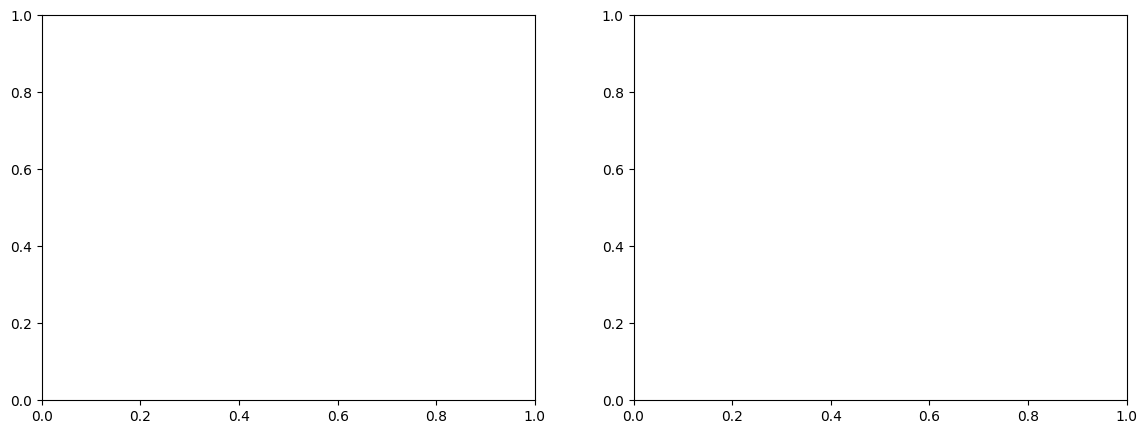

In [17]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history['train_acc'], label='Training', linewidth=2)
ax1.plot(history['val_acc'], label='Validation', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history['train_loss'], label='Training', linewidth=2)
ax2.plot(history['val_loss'], label='Validation', linewidth=2)
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/resnet50_transfer_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best validation accuracy: {max(history['val_acc']):.4f}")
print(f"Best epoch: {np.argmax(history['val_acc']) + 1}")

## Step 7: Optional - Fine-tune All Layers (Advanced)

If you want to further improve accuracy, unfreeze the entire backbone and train with a lower learning rate.

In [ ]:
# Uncomment to fine-tune entire backbone with lower learning rate
# This can improve accuracy further but requires more training time

# model.unfreeze_backbone()
# print(f"Trainable parameters after unfreeze: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# history_finetune = train_model(
#     model=model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     epochs=50,  # Fewer epochs for fine-tuning
#     learning_rate=1e-4,  # Lower learning rate
#     device=device,
#     model_name='exp_resnet50_transfer_finetune',
#     class_weights=class_weights,
#     weight_decay=1e-5
# )